In [1]:
# Instalar bibliotecas necessárias para o IP-Adapter
!pip install diffusers transformers accelerate peft Pillow opencv-python matplotlib

In [2]:
import os
import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from diffusers import StableDiffusionInpaintPipeline

# Configuração de caminhos do dataset VITON-HD
BASE_DIR = "../data/test"
IMAGE_DIR = os.path.join(BASE_DIR, "image")
CLOTH_DIR = os.path.join(BASE_DIR, "cloth")
MASK_DIR = os.path.join(BASE_DIR, "cloth-mask")

# Vamos usar exatamente a modelo e a camisola que deu o erro do leopardo!
ficheiro_alvo = "00035_00.jpg"
nome_mascara = ficheiro_alvo.replace(".jpg", ".png") # A máscara costuma ser png

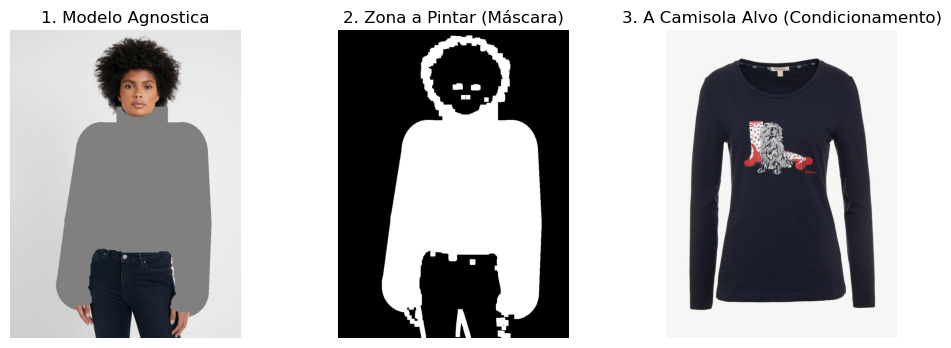

In [3]:
img_agnostic = Image.open(os.path.join(BASE_DIR, "agnostic", ficheiro_alvo)).convert("RGB")
img_cloth = Image.open(os.path.join(CLOTH_DIR, ficheiro_alvo)).convert("RGB") # A NOSSA CAMISOLA DA BARBOUR!

# Gerar a máscara baseada nos pixéis cinzentos (como fizemos na app)
cv_agnostic = cv2.cvtColor(np.array(img_agnostic), cv2.COLOR_RGB2BGR)
lower_gray = np.array([100, 100, 100], dtype=np.uint8)
upper_gray = np.array([150, 150, 150], dtype=np.uint8)
mask_cinzenta = cv2.inRange(cv_agnostic, lower_gray, upper_gray)

kernel = np.ones((15, 15), np.uint8)
mask_dilated = cv2.dilate(mask_cinzenta, kernel, iterations=1)
img_mask = Image.fromarray(mask_dilated).convert("L")

# Visualizar o que vamos enviar para a IA
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(img_agnostic); axs[0].set_title("1. Modelo Agnostica"); axs[0].axis('off')
axs[1].imshow(img_mask, cmap='gray'); axs[1].set_title("2. Zona a Pintar (Máscara)"); axs[1].axis('off')
axs[2].imshow(img_cloth); axs[2].set_title("3. A Camisola Alvo (Condicionamento)"); axs[2].axis('off')
plt.show()

In [4]:
import os
import gc
import torch
from diffusers import StableDiffusionInpaintPipeline

print("⏳ A carregar o modelo Base e o IP-Adapter...")
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# A CHAVE MÁGICA: Desliga o limite artificial de memória do Mac!
# Isto permite ao Mac usar o disco (Swap) se a RAM acabar.
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

# Limpeza profunda de memória antes de começar
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

# Usamos MPS para o Mac
device = "mps" if torch.backends.mps.is_available() else "cpu"
dtype = torch.float32

# 1. Carregar o modelo Inpainting normal
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting", 
    torch_dtype=dtype,
    safety_checker=None,              
    requires_safety_checker=False 
).to(device)

# 2. O UPGRADE TÉCNICO: Ligar o "Nervo Ótico" (IP-Adapter)
pipe.load_ip_adapter("h94/IP-Adapter", subfolder="models", weight_name="ip-adapter_sd15.bin")

# Nível de "obediência" à imagem (1.0 = Obriga a IA a usar a imagem da roupa)
pipe.set_ip_adapter_scale(1.0) 

print("✅ Motor de Deep Learning Avançado pronto!")

⏳ A carregar o modelo Base e o IP-Adapter...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /Users/danielgoncalves/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /Users/danielgoncalves/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /Users/danielgoncalves/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /Users/danielgoncalves/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

✅ Motor de Deep Learning Avançado pronto!


🎨 A gerar a fusão (Modo Otimizado)...


  0%|          | 0/10 [00:00<?, ?it/s]

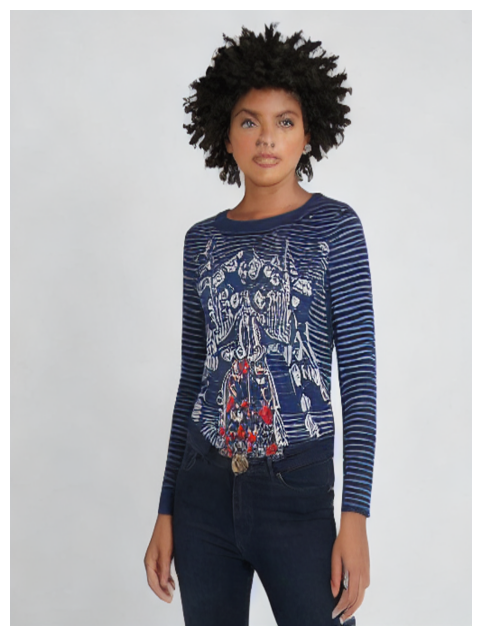

In [6]:
# Célula 5: Preparação das variáveis e Execução Otimizada

# 1. Preparar as variáveis necessárias
img_agnostic_resized = img_agnostic.resize((512, 512))
img_mask_resized = img_mask.resize((512, 512))

print("🎨 A gerar a fusão (Modo Otimizado)...")

# Limpar memória antes de executar
if device == "mps": torch.mps.empty_cache()

# Executar a pipeline de geração
resultado = pipe(
    prompt="A fashion model wearing the garment",
    negative_prompt="deformed, bad anatomy, blurry",
    image=img_agnostic_resized,
    mask_image=img_mask_resized,
    ip_adapter_image=img_cloth,
    num_inference_steps=10, 
    guidance_scale=5.0,
    generator=torch.Generator("cpu").manual_seed(42)
).images[0]

# Restaurar tamanho original
imagem_final = resultado.resize(img_agnostic.size)

# Visualizar resultado
plt.figure(figsize=(6, 8))
plt.imshow(imagem_final)
plt.axis('off')
plt.show()